# Liu 2016 baseline — step-by-step notebook

这个 notebook 展示完整流程：

1. 设置项目环境和依赖路径
2. 加载 BLE CS 场景与段落定义
3. 读取并滤波多通道变量
4. 运行 Liu 2016 基线算法
5. 打印整体误差与单段诊断
6. 绘制并保存窗口级 BPM 曲线


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path('/Users/shenmeichen/26 X program/ble_hci_sensing-main')
if (project_root / "src").is_dir():
    sys.path.insert(0, str(project_root / "src"))
else:
    raise FileNotFoundError('Project root not found: /Users/shenmeichen/26 X program/ble_hci_sensing-main')

from ble_analysis.bootstrap import init_notebook
from ble_analysis.chfusion import ChFusionConfig, _overall_rel_error, load_multichannel_for_scenario
from ble_analysis.liu_2016 import run_liu_2016_benchmark
from ble_analysis.scenarios import load_scenario, print_scenario_summary
from ble_analysis.segments import BreathMetricParams, FilterParams

env = init_notebook(project_root)
project_root = env["project_root"]
FIGURES_DIR = env["FIGURES_DIR"]
REPORTS_DIR = env["REPORTS_DIR"]
CACHE_DIR = project_root / "outputs" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Python executable:", sys.executable)
print("sys.path[0]:", sys.path[0])

print("Project root:", project_root)
print("FIGURES_DIR:", FIGURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("CACHE_DIR:", CACHE_DIR)


Python executable: /opt/anaconda3/bin/python
sys.path[0]: /Users/shenmeichen/26 X program/ble_hci_sensing-main/src
Project root: /Users/shenmeichen/26 X program/ble_hci_sensing-main
FIGURES_DIR: /Users/shenmeichen/26 X program/ble_hci_sensing-main/outputs/figures
REPORTS_DIR: /Users/shenmeichen/26 X program/ble_hci_sensing-main/outputs/reports
CACHE_DIR: /Users/shenmeichen/26 X program/ble_hci_sensing-main/outputs/cache


In [2]:
# 加载场景并打印段落定义
scenario_id = 'cs_091339'
scenario = load_scenario(scenario_id, project_root=project_root)
print(f"Scenario: {scenario_id}")
print_scenario_summary(scenario)


Scenario: cs_091339
=== Scenario: cs_091339 — CS metal-plate breathing script (2026-01-13) ===
Globecom metal-plate protocol: 9 segments (7 breath + 2 apnea), same BPM GT as 095806 run.
Data: sampleData/CS_frames_all_20260113_091339.jsonl
Source: notebooks/load_cs_saved_frames_show_analysis.ipynb
段落     起始index      结束index      类型         长度        
------------------------------------------------------------
1a     131          244          breath     114       
1b     244          361          breath     118       
2a     361          419          breath     59        
2b     437          473          breath     37        
3      473          586          breath     114       
4a     586          648          breath     63        
4b     666          702          breath     37        
p1     419          437          apnea      19        
p2     648          666          apnea      19        

✓ 共 9 段：7 breath + 2 apnea


In [3]:
# 准备滤波与度量参数
filter_params = FilterParams()
metric_params = BreathMetricParams()
cfg = ChFusionConfig(
    breath_freq_low=metric_params.breath_freq_low,
    breath_freq_high=metric_params.breath_freq_high,
    window_length_sec=metric_params.window_length_sec,
    step_length_sec=metric_params.step_length_sec,
)

multichannel_by_var, fs, skipped = load_multichannel_for_scenario(
    scenario,
    project_root=project_root,
    filter_params=filter_params,
    cache_dir=str(CACHE_DIR),
    verbose=True,
)

print(f"fs={fs:.2f} Hz")
print("available variables:", list(multichannel_by_var.keys()))
print("cache skip status:", skipped)


✓ [远程幅值 remote] 缓存命中 9/9 段 | (已缓存，无需原始数据)
✓ [本地幅值 local] 缓存命中 9/9 段 | (已缓存，无需原始数据)
✓ [总相位 phase] 缓存命中 9/9 段 | (已缓存，无需原始数据)
✓ 全部 3 变量滤波缓存命中，跳过原始数据加载与分段
fs=1.80 Hz
available variables: ['remote_amplitudes', 'local_amplitudes', 'phases']
cache skip status: True


In [4]:
# 运行 Liu 2016 baseline 算法
bench = run_liu_2016_benchmark(
    None,
    scenario.segment_config,
    filter_params=filter_params,
    metric_params=metric_params,
    config=cfg,
    verbose=True,
    cache_dir=str(CACHE_DIR),
    multichannel_by_var=multichannel_by_var,
)

stats = _overall_rel_error(bench["results"], "liu_2016")
print("Liu 2016 cross-window mean error:")
print(stats)
print("segments processed:", sorted(bench["results"].keys()))


Liu 2016 cross-window mean error:
{'mean_rel_err_pct': 14.61745341694331, 'std_rel_err_pct': 8.499552940425778, 'n_segments': 7}
segments processed: ['1a', '1b', '2a', '2b', '3', '4a', '4b', 'p1', 'p2']


Segment row keys: ['bpm_mean', 'bpm_per_window', 'bpm_signed_err_per_window', 'bpm_rel_err', 'bpm_rel_err_std', 'n_windows']
Segment summary: {'bpm_mean': 15.086256209543885, 'bpm_per_window': array([16.45009785, 16.45009785, 16.36203523, 16.36203523, 16.18590998,
       16.18590998, 16.06849315, 15.92172211, 15.71624266, 15.65753425,
       15.56947162, 15.36399217, 15.27592955, 14.80626223, 14.74755382,
       14.57142857, 14.65949119, 14.71819961, 14.77690802, 14.89432485,
       14.71819961, 14.71819961, 14.57142857, 14.6888454 , 14.86497065,
       15.09980431, 15.33463796, 15.59882583, 15.95107632, 16.06849315,
       16.18590998, 16.42074364, 12.3111546 , 12.34050881, 15.45205479,
       15.24657534, 14.48336595, 10.37377691, 13.19178082]), 'bpm_signed_err_per_window': array([ 2.41009785,  2.41009785,  2.32203523,  2.32203523,  2.14590998,
        2.14590998,  2.02849315,  1.88172211,  1.67624266,  1.61753425,
        1.52947162,  1.32399217,  1.23592955,  0.76626223,  0.7075538

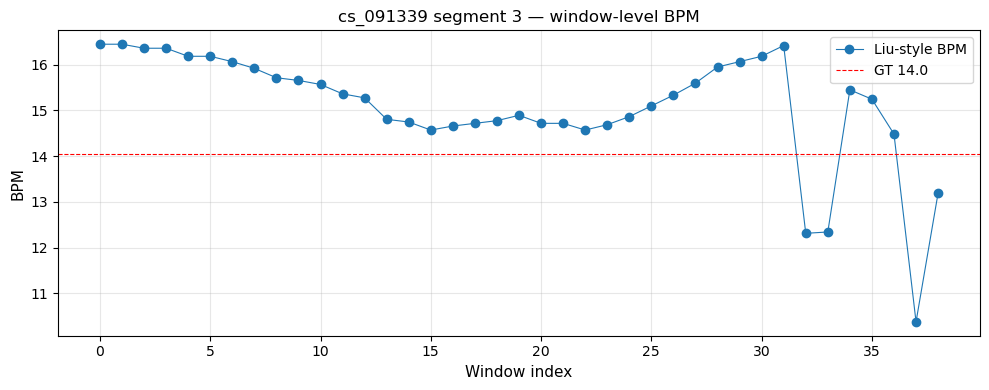

Saved figure: /Users/shenmeichen/26 X program/ble_hci_sensing-main/outputs/figures/liu_2016_cs_091339_segment_3.png


In [5]:
# 打印单个段落结果与诊断
seg_name = '3'
row = bench["results"][seg_name]
print("Segment row keys:", list(row["liu_2016"].keys()))
print("Segment summary:", row["liu_2016"])

bpm_est = row["liu_2016"]["bpm_per_window"]
bpm_gt = row["bpm_gt"]
windows = np.arange(len(bpm_est))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(windows, bpm_est, marker="o", label="Liu-style BPM")
ax.axhline(bpm_gt, color="red", linestyle="--", label=f"GT {bpm_gt:.1f}")
ax.set_xlabel("Window index")
ax.set_ylabel("BPM")
ax.set_title(f"{scenario_id} segment {seg_name} — window-level BPM")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

fig_path = FIGURES_DIR / f"liu_2016_{scenario_id}_segment_{seg_name}.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Saved figure: {fig_path}")
